<a href="https://colab.research.google.com/github/dinindriati-gif/sarbagita-landcover-projection/blob/main/Dini_Indriati_Peta_Proyeksi_Tutupan_Lahan_Sarbagita.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**MOUNT GOOGLE DRIVE**

In [1]:
import os

In [2]:
# Membaca Penyimpanan Drive, setujui izin akses ketika muncul pop up perizinan
from google.colab import drive
drive.mount('/content/drive') # Penyimpanan di atur ke folder '/content/drive' (default)

Mounted at /content/drive


In [3]:
# Menentukan lokasi penyimpanan
loc = '/content/drive/MyDrive/ATRBPN'

In [4]:
# Mengubah ke penyimpanan yang sudah kita deifinisikan sebelumnya
os.chdir(loc)

# Cek lokasi penyimpanan apakah sudah sesuai dengan yang sudah kita tenetukan
print('Working Directory: ',os.getcwd())

Working Directory:  /content/drive/MyDrive/ATRBPN


**INSTAL LIBRARY**

In [5]:
# Instalasi Library
!pip install geopandas rasterio rioxarray openpyxl scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.4/72.4 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 26.2 MB/s eta 0:00:00
  Attempting uninstall: xarray
    Found existing installation: xarray 2025.12.0
    Uninstalling xarray-2025.12.0:
      Successfully uninstalled xarray-2025.12.0


In [6]:
# Import Library
import geopandas as gpd
import rasterio
from rasterio.mask import mask
from shapely.geometry import Point
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, cohen_kappa_score

**TRAINING SAMPLE**

In [8]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from shapely.geometry import Point

# Pemetaan Kode & Nama Kelas (Skema 4 Kelas)
CLASS_NAMES = {
    1: "Hutan / Vegetasi Lebat",  # Kode 1
    2: "Pertanian / Sawah",  # Kode 2
    4: "Lahan Terbangun / Permukiman",  # Kode 4 (Termasuk Lahan Terbuka)
    5: "Badan Air / Perairan",  # Kode 5
}


def classify_rgb_4classes(raster_path, lake_shp_path):
    print(f"Memproses klasifikasi untuk titik sampel: {raster_path}...")
    with rasterio.open(raster_path) as src:
        r = src.read(1).astype(float)
        g = src.read(2).astype(float)
        b = src.read(3).astype(float)
        transform = src.transform
        crs = src.crs

    valid = (r > 10) & (g > 10) & (b > 10)
    brightness = (r + g + b) / 3.0

    # 1. Integrasi SHP Danau Batur
    lake_gdf = gpd.read_file(lake_shp_path)
    if lake_gdf.crs != crs:
        lake_gdf = lake_gdf.to_crs(crs)

    lake_shapes = [(geom, 1) for geom in lake_gdf.geometry]
    lake_mask_from_shp = (
        rasterize(
            shapes=lake_shapes,
            out_shape=r.shape,
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )
        == 1
    )

    classified = np.zeros_like(r, dtype=np.uint8)

    # A. BADAN AIR (Kode 5)
    sea_water = valid & (brightness < 40) & (b > r) & (b >= g * 0.9)
    lake_water = valid & lake_mask_from_shp
    water_mask = sea_water | lake_water
    classified[water_mask] = 5

    # B. HUTAN / VEGETASI LEBAT (Kode 1)
    forest_mask = (
        valid
        & (~water_mask)
        & (g > r * 1.15)
        & (g > b * 1.10)
        & (brightness < 85)
    )
    classified[forest_mask] = 1

    # C. PERTANIAN / SAWAH (Kode 2)
    agri_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (g >= r * 1.015)
        & (g >= b * 0.98)
        & (brightness >= 70)
        & (brightness <= 165)
    )
    classified[agri_mask] = 2

    # D. LAHAN TERBANGUN / PERMUKIMAN (Kode 4)
    # Menampung seluruh sisa area non-vegetasi dan non-air
    built_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (classified == 0)
    )
    classified[built_mask] = 4

    return classified, transform, crs


# 1. Eksekusi Klasifikasi 2020 & 2023 untuk pembuatan mask konsistensi
lake_shp = "danau_batur.shp"
class_2020, transform, crs = classify_rgb_4classes(
    "Sarbagita_2020.tif", lake_shp
)
class_2023, _, _ = classify_rgb_4classes("Sarbagita_2023.tif", lake_shp)

# 2. Filter Area Stabil/Konsisten (2020 dan 2023 tidak berubah)
mask_konsisten = (class_2020 == class_2023) & (class_2020 > 0)

# 3. Stratified Random Sampling (100 Titik per Kelas)
samples_per_class = 100
np.random.seed(42)  # Menjaga reproduksibilitas hasil

sample_ids, points, landcover_class, landcover_name = [], [], [], []
current_id = 1

print("\nMengambil titik acuan sampel (4 Kelas)...")
for code, name in CLASS_NAMES.items():
    class_mask = mask_konsisten & (class_2020 == code)
    valid_y, valid_x = np.where(class_mask)

    if len(valid_y) > 0:
        n_take = min(samples_per_class, len(valid_y))
        chosen_indices = np.random.choice(
            len(valid_y), size=n_take, replace=False
        )

        for idx in chosen_indices:
            r_idx, c_idx = valid_y[idx], valid_x[idx]
            # Konversi piksel raster ke koordinat geografis/UTM
            x, y = transform * (c_idx + 0.5, r_idx + 0.5)

            sample_ids.append(current_id)
            points.append(Point(x, y))
            landcover_class.append(code)
            landcover_name.append(name)
            current_id += 1

        print(f"  - Kelas [{code}] {name}: Berhasil mengambil {n_take} titik.")

# 4. Ekspor ke Shapefile
output_shp = "training_sample_tutupan_lahan.shp"
gdf = gpd.GeoDataFrame(
    {"id": sample_ids, "class": landcover_class, "class_name": landcover_name},
    geometry=points,
    crs=crs,
)
gdf.to_file(output_shp)

print(f"\nSELESAI! File shapefile 4 kelas berhasil dibuat: {output_shp}")

Memproses klasifikasi untuk titik sampel: Sarbagita_2020.tif...
Memproses klasifikasi untuk titik sampel: Sarbagita_2023.tif...

Mengambil titik acuan sampel (4 Kelas)...
  - Kelas [1] Hutan / Vegetasi Lebat: Berhasil mengambil 100 titik.
  - Kelas [2] Pertanian / Sawah: Berhasil mengambil 100 titik.
  - Kelas [4] Lahan Terbangun / Permukiman: Berhasil mengambil 100 titik.
  - Kelas [5] Badan Air / Perairan: Berhasil mengambil 100 titik.

SELESAI! File shapefile 4 kelas berhasil dibuat: training_sample_tutupan_lahan.shp


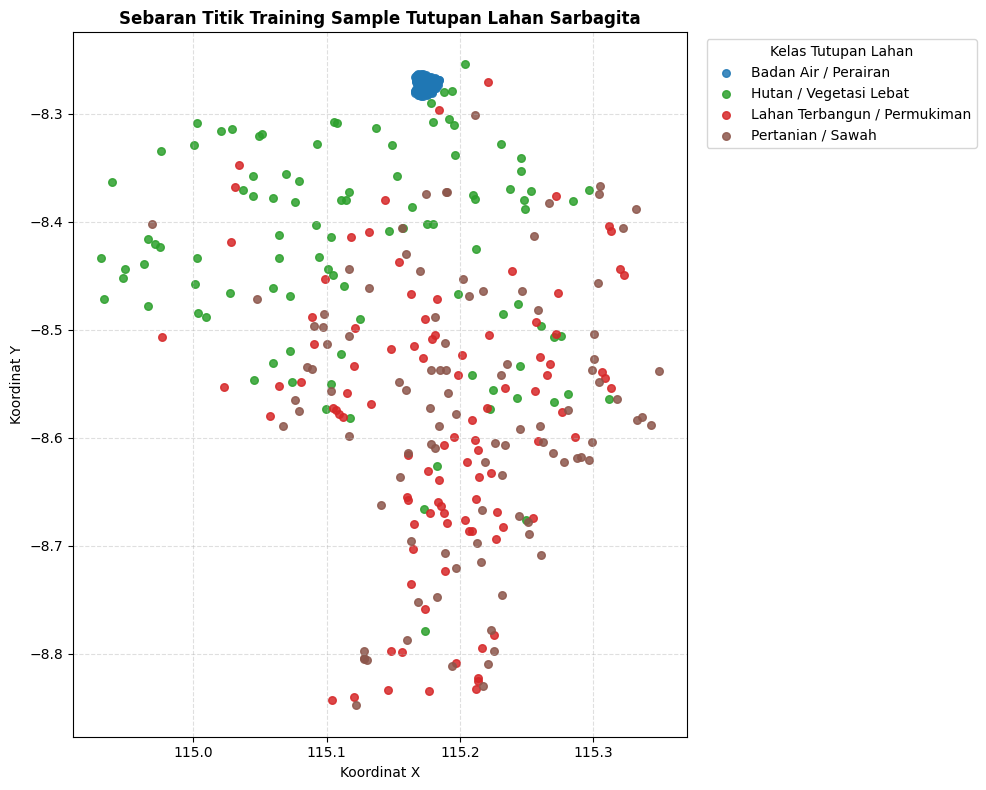

,Jumlah Sampel,count
0,Hutan / Vegetasi Lebat,100
1,Pertanian / Sawah,100
2,Lahan Terbangun / Permukiman,100
3,Badan Air / Perairan,100


In [9]:
import matplotlib.pyplot as plt

gdf_samples = gpd.read_file("training_sample_tutupan_lahan.shp")

color_dict = {
    "Hutan / Vegetasi Lebat": "#2ca02c",  # Hijau
    "Pertanian / Sawah": "#8c564b",  # Cokelat
    "Lahan Terbuka / Semak": "#bcbd22",  # Kuning
    "Lahan Terbangun / Permukiman": "#d62728",  # Merah
    "Badan Air / Perairan": "#1f77b4",  # Biru
}

fig, ax = plt.subplots(figsize=(10, 8))

for class_name, group in gdf_samples.groupby("class_name"):
    ax.scatter(
        group.geometry.x,
        group.geometry.y,
        label=class_name,
        color=color_dict.get(class_name, "#7f7f7f"),
        s=30,
        alpha=0.85,
    )

plt.title(
    "Sebaran Titik Training Sample Tutupan Lahan Sarbagita",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Koordinat X")
plt.ylabel("Koordinat Y")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend(
    title="Kelas Tutupan Lahan",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=True,
)

plt.tight_layout()
plt.show()

# Ringkasan jumlah per kelas
display(
    gdf_samples["class_name"]
    .value_counts()
    .reset_index()
    .rename(columns={"index": "Nama Kelas", "class_name": "Jumlah Sampel"})
)

**Peta klasifikasi tutupan lahan Sarbagita Tahun 2020 (raster/.tiff)**

In [10]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from scipy.ndimage import median_filter


def generate_landcover_2020_4classes(
    input_raster, lake_shp_path, output_raster
):
    print(
        f"Memproses klasifikasi 2020 (Skema 4 Kelas): {input_raster}..."
    )

    with rasterio.open(input_raster) as src:
        r = src.read(1).astype(float)
        g = src.read(2).astype(float)
        b = src.read(3).astype(float)
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs

    valid = (r > 10) & (g > 10) & (b > 10)
    brightness = (r + g + b) / 3.0

    # 1. Integrasi SHP Danau Batur
    lake_gdf = gpd.read_file(lake_shp_path)
    if lake_gdf.crs != crs:
        lake_gdf = lake_gdf.to_crs(crs)

    lake_shapes = [(geom, 1) for geom in lake_gdf.geometry]
    lake_mask_from_shp = (
        rasterize(
            shapes=lake_shapes,
            out_shape=r.shape,
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )
        == 1
    )

    classified = np.zeros_like(r, dtype=np.uint8)

    # A. BADAN AIR (Kode 5)
    sea_water = valid & (brightness < 40) & (b > r) & (b >= g * 0.9)
    lake_water = valid & lake_mask_from_shp
    water_mask = sea_water | lake_water
    classified[water_mask] = 5

    # B. HUTAN / VEGETASI LEBAT (Kode 1)
    forest_mask = (
        valid
        & (~water_mask)
        & (g > r * 1.15)
        & (g > b * 1.10)
        & (brightness < 85)
    )
    classified[forest_mask] = 1

    # C. PERTANIAN / SAWAH (Kode 2)
    agri_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (g >= r * 1.015)
        & (g >= b * 0.98)
        & (brightness >= 70)
        & (brightness <= 165)
    )
    classified[agri_mask] = 2

    # D. LAHAN TERBANGUN / PERMUKIMAN (Kode 4)
    # Semua sisa daratan non-vegetasi dan non-air langsung masuk ke Lahan Terbangun
    built_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (classified == 0)
    )
    classified[built_mask] = 4

    # =========================================================================
    # POST-PROCESSING: SPATIAL MEDIAN FILTERING (3x3)
    # =========================================================================
    print("Menerapkan Median Filter 3x3...")
    smoothed_classified = median_filter(classified, size=3)

    # Kunci ulang Badan Air agar tidak terpengaruh filter
    smoothed_classified[water_mask] = 5

    # Simpan Hasil Klasifikasi
    profile.update(
        dtype=rasterio.uint8, count=1, nodata=0, compress="lzw"
    )

    with rasterio.open(output_raster, "w", **profile) as dst:
        dst.write(smoothed_classified.astype(np.uint8), 1)

    print(f"BERHASIL! Hasil 2020 (4 Kelas) tersimpan di: {output_raster}\n")


# Eksekusi Klasifikasi 2020
generate_landcover_2020_4classes(
    "Sarbagita_2020.tif", "danau_batur.shp", "Sarbagita_2020_tutupan_lahan.tif"
)

Memproses klasifikasi 2020 (Skema 4 Kelas): Sarbagita_2020.tif...
Menerapkan Median Filter 3x3...
BERHASIL! Hasil 2020 (4 Kelas) tersimpan di: Sarbagita_2020_tutupan_lahan.tif



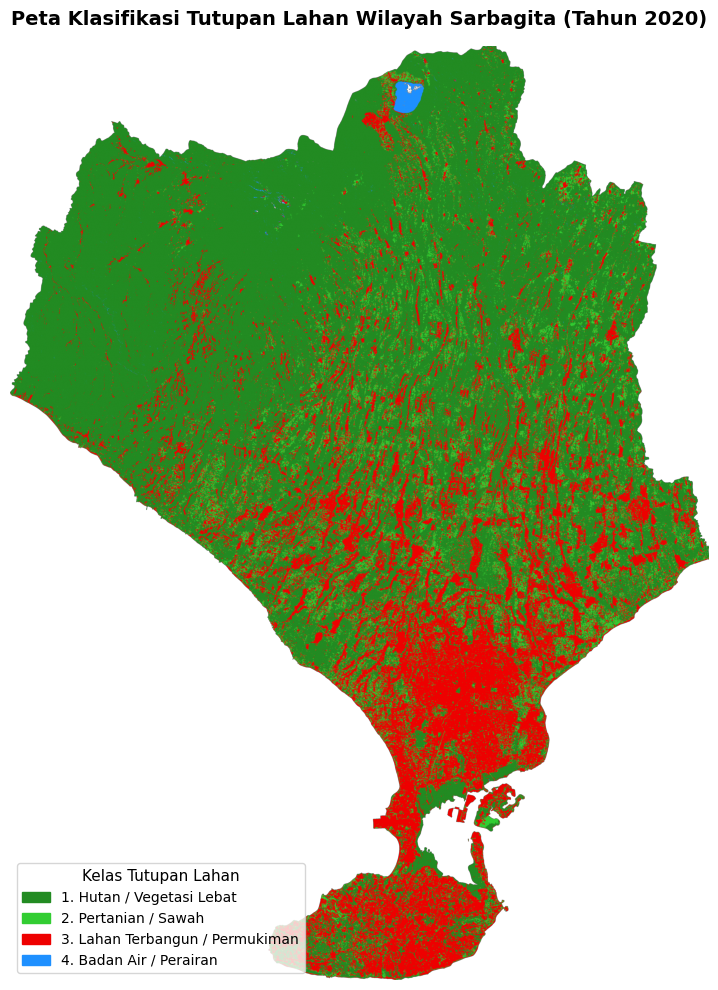

In [20]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio

# 1. Pemetaan Kode Kelas Baru (Urut 1 - 4)
color_dict = {
    1: "#228B22",  # Hijau Tua (Hutan / Vegetasi Lebat)
    2: "#32CD32",  # Hijau Muda (Pertanian / Sawah)
    3: "#EE0000",  # Merah (Lahan Terbangun / Permukiman)
    4: "#1E90FF",  # Biru (Badan Air / Perairan)
}

class_names = {
    1: "Hutan / Vegetasi Lebat",
    2: "Pertanian / Sawah",
    3: "Lahan Terbangun / Permukiman",
    4: "Badan Air / Perairan",
}


def plot_landcover_map(raster_path, title):
    with rasterio.open(raster_path) as src:
        data = src.read(1)

    # 2. Remap nilai piksel lama (1, 2, 4, 5) ke kode baru (1, 2, 3, 4)
    data_remapped = np.zeros_like(data, dtype=np.uint8)
    data_remapped[data == 1] = 1  # Hutan
    data_remapped[data == 2] = 2  # Pertanian
    data_remapped[data == 4] = 3  # Lahan Terbangun (Lama: 4 -> Baru: 3)
    data_remapped[data == 5] = 4  # Badan Air (Lama: 5 -> Baru: 4)

    # 3. Custom Colormap urut 1 - 4
    colors = [color_dict[i] for i in sorted(color_dict.keys())]
    cmap = ListedColormap(colors)

    # Masking nilai 0 (NoData)
    data_masked = np.ma.masked_where(data_remapped == 0, data_remapped)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Tampilkan Raster (Nilai 1 sampai 4)
    im = ax.imshow(data_masked, cmap=cmap, vmin=1, vmax=4)

    # 4. Buat Legenda Manual
    patches = [
        mpatches.Patch(
            color=color_dict[code], label=f"{code}. {class_names[code]}"
        )
        for code in sorted(color_dict.keys())
    ]

    ax.legend(
        handles=patches,
        loc="lower left",
        title="Kelas Tutupan Lahan",
        fontsize=10,
        title_fontsize=11,
        frameon=True,
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")  # Sembunyikan sumbu koordinat piksel

    plt.tight_layout()
    plt.show()


# Tampilkan Peta 2020
plot_landcover_map(
    "Sarbagita_2020_tutupan_lahan.tif",
    "Peta Klasifikasi Tutupan Lahan Wilayah Sarbagita (Tahun 2020)",
)

**Peta klasifikasi tutupan lahan Sarbagita Tahun 2023 (raster/.tiff)**

In [12]:
import geopandas as gpd
import numpy as np
import rasterio
from rasterio.features import rasterize
from scipy.ndimage import median_filter


def generate_landcover_2023_4classes(
    input_raster, lake_shp_path, output_raster
):
    print(
        f"Memproses klasifikasi 2023 (Skema 4 Kelas): {input_raster}..."
    )

    with rasterio.open(input_raster) as src:
        r = src.read(1).astype(float)
        g = src.read(2).astype(float)
        b = src.read(3).astype(float)
        profile = src.profile.copy()
        transform = src.transform
        crs = src.crs

    valid = (r > 10) & (g > 10) & (b > 10)
    brightness = (r + g + b) / 3.0

    lake_gdf = gpd.read_file(lake_shp_path)
    if lake_gdf.crs != crs:
        lake_gdf = lake_gdf.to_crs(crs)

    lake_shapes = [(geom, 1) for geom in lake_gdf.geometry]
    lake_mask_from_shp = (
        rasterize(
            shapes=lake_shapes,
            out_shape=r.shape,
            transform=transform,
            fill=0,
            dtype=np.uint8,
        )
        == 1
    )

    classified = np.zeros_like(r, dtype=np.uint8)

    # A. BADAN AIR (Kode 5)
    sea_water = valid & (brightness < 40) & (b > r) & (b >= g * 0.9)
    lake_water = valid & lake_mask_from_shp
    water_mask = sea_water | lake_water
    classified[water_mask] = 5

    # B. HUTAN / VEGETASI LEBAT (Kode 1)
    forest_mask = (
        valid
        & (~water_mask)
        & (g > r * 1.15)
        & (g > b * 1.10)
        & (brightness < 85)
    )
    classified[forest_mask] = 1

    # C. PERTANIAN / SAWAH (Kode 2)
    agri_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (g >= r * 1.015)
        & (g >= b * 0.98)
        & (brightness >= 70)
        & (brightness <= 165)
    )
    classified[agri_mask] = 2

    # D. LAHAN TERBANGUN / PERMUKIMAN (Kode 4)
    built_mask = (
        valid
        & (~water_mask)
        & (~forest_mask)
        & (~agri_mask)
        & (classified == 0)
    )
    classified[built_mask] = 4

    # =========================================================================
    # POST-PROCESSING: SPATIAL MEDIAN FILTERING (3x3)
    # =========================================================================
    print("Menerapkan Median Filter 3x3...")
    smoothed_classified = median_filter(classified, size=3)

    # Kunci ulang Badan Air
    smoothed_classified[water_mask] = 5

    # Simpan Hasil Klasifikasi
    profile.update(
        dtype=rasterio.uint8, count=1, nodata=0, compress="lzw"
    )

    with rasterio.open(output_raster, "w", **profile) as dst:
        dst.write(smoothed_classified.astype(np.uint8), 1)

    print(f"BERHASIL! Hasil 2023 (4 Kelas) tersimpan di: {output_raster}\n")


# Eksekusi Klasifikasi 2023
generate_landcover_2023_4classes(
    "Sarbagita_2023.tif", "danau_batur.shp", "Sarbagita_2023_tutupan_lahan.tif"
)

Memproses klasifikasi 2023 (Skema 4 Kelas): Sarbagita_2023.tif...
Menerapkan Median Filter 3x3...
BERHASIL! Hasil 2023 (4 Kelas) tersimpan di: Sarbagita_2023_tutupan_lahan.tif



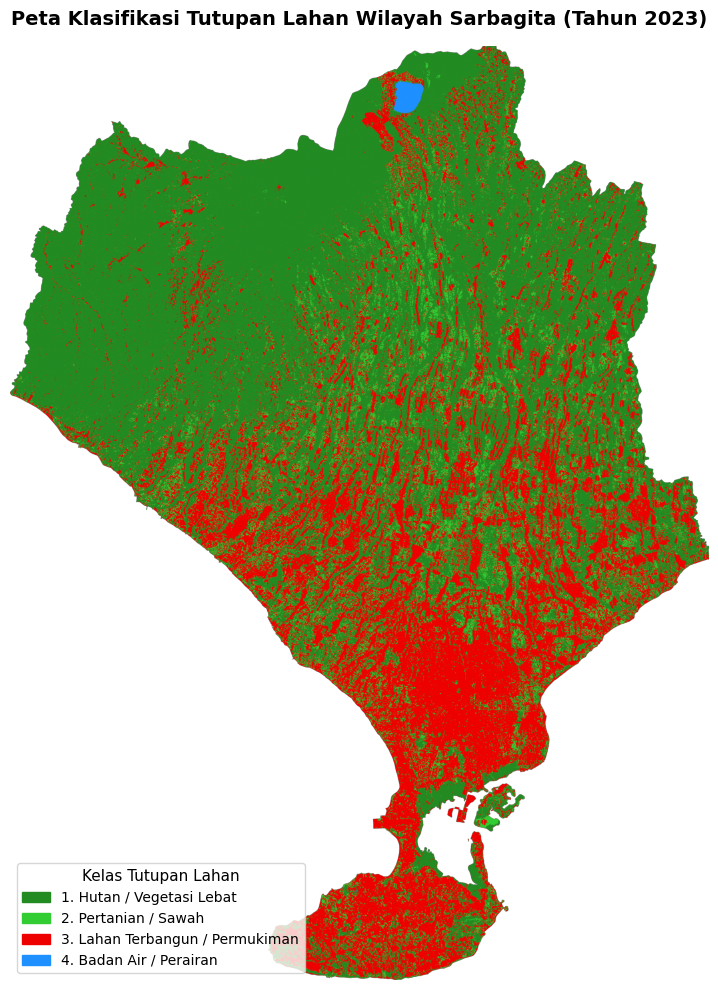

In [21]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio

# 1. Pemetaan Kode Kelas Baru (Urut 1 - 4)
color_dict = {
    1: "#228B22",  # Hijau Tua (Hutan / Vegetasi Lebat)
    2: "#32CD32",  # Hijau Muda (Pertanian / Sawah)
    3: "#EE0000",  # Merah (Lahan Terbangun / Permukiman)
    4: "#1E90FF",  # Biru (Badan Air / Perairan)
}

class_names = {
    1: "Hutan / Vegetasi Lebat",
    2: "Pertanian / Sawah",
    3: "Lahan Terbangun / Permukiman",
    4: "Badan Air / Perairan",
}


def plot_landcover_map(raster_path, title):
    with rasterio.open(raster_path) as src:
        data = src.read(1)

    # 2. Remap nilai piksel lama (1, 2, 4, 5) ke kode baru (1, 2, 3, 4)
    data_remapped = np.zeros_like(data, dtype=np.uint8)
    data_remapped[data == 1] = 1  # Hutan
    data_remapped[data == 2] = 2  # Pertanian
    data_remapped[data == 4] = 3  # Lahan Terbangun (Lama: 4 -> Baru: 3)
    data_remapped[data == 5] = 4  # Badan Air (Lama: 5 -> Baru: 4)

    # 3. Custom Colormap urut 1 - 4
    colors = [color_dict[i] for i in sorted(color_dict.keys())]
    cmap = ListedColormap(colors)

    # Masking nilai 0 (NoData)
    data_masked = np.ma.masked_where(data_remapped == 0, data_remapped)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Tampilkan Raster (Nilai 1 sampai 4)
    im = ax.imshow(data_masked, cmap=cmap, vmin=1, vmax=4)

    # 4. Buat Legenda Manual
    patches = [
        mpatches.Patch(
            color=color_dict[code], label=f"{code}. {class_names[code]}"
        )
        for code in sorted(color_dict.keys())
    ]

    ax.legend(
        handles=patches,
        loc="lower left",
        title="Kelas Tutupan Lahan",
        fontsize=10,
        title_fontsize=11,
        frameon=True,
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")  # Sembunyikan sumbu koordinat piksel

    plt.tight_layout()
    plt.show()

# Tampilkan Peta 2023
plot_landcover_map(
    "Sarbagita_2023_tutupan_lahan.tif",
    "Peta Klasifikasi Tutupan Lahan Wilayah Sarbagita (Tahun 2023)",
)

**Peta Proyeksi Tutupan Lahan Sarbagita Tahun 2026**

In [14]:
import numpy as np
import rasterio
from sklearn.ensemble import RandomForestClassifier

print("1. Memuat raster 2020 & 2023...")
with rasterio.open("Sarbagita_2020_tutupan_lahan.tif") as src20:
    lc_2020 = src20.read(1)
    profile = src20.profile.copy()

with rasterio.open("Sarbagita_2023_tutupan_lahan.tif") as src23:
    lc_2023 = src23.read(1)

# Masking piksel valid (abaikan background / NoData = 0)
valid_mask = (lc_2020 > 0) & (lc_2023 > 0)
water_restriction = lc_2023 == 5

# 2. Driving Factors (Proxy Spasial & Proksimitas)
rows, cols = lc_2020.shape
row_grid, col_grid = np.indices((rows, cols))

y_factor = (row_grid / float(rows)).astype(np.float32)
x_factor = (col_grid / float(cols)).astype(np.float32)
center_y, center_x = rows // 2, cols // 2
dist_center = (
    np.sqrt((row_grid - center_y) ** 2 + (col_grid - center_x) ** 2)
    / np.sqrt(rows**2 + cols**2)
).astype(np.float32)

# Sub-sampling data latih (Ambil max 100.000 piksel acak agar sangat cepat)
valid_indices = np.argwhere(valid_mask)
n_samples = min(100000, len(valid_indices))
np.random.seed(42)
sample_idx = valid_indices[
    np.random.choice(len(valid_indices), n_samples, replace=False)
]

r_idx, c_idx = sample_idx[:, 0], sample_idx[:, 1]

X_train_sub = np.column_stack(
    [
        lc_2020[r_idx, c_idx],
        y_factor[r_idx, c_idx],
        x_factor[r_idx, c_idx],
        dist_center[r_idx, c_idx],
    ]
)
y_train_sub = lc_2023[r_idx, c_idx]

# 3. Melatih Model (Sangat Cepat karena Sub-sampling)
print("2. Melatih model Random Forest...")
model = RandomForestClassifier(
    n_estimators=50, max_depth=15, random_state=42, n_jobs=-1
)
model.fit(X_train_sub, y_train_sub)

# 4. Prediksi Proyeksi 2026 secara Bertahap (Chunk-by-chunk agar RAM hemat)
print("3. Memprediksi tutupan lahan 2026...")
lc_2026_matrix = np.zeros_like(lc_2020, dtype=np.uint8)

# Memproses per 500 baris agar tidak membebani memori
chunk_size = 500
for i in range(0, rows, chunk_size):
    row_end = min(i + chunk_size, rows)
    chunk_mask = valid_mask[i:row_end, :]

    if not np.any(chunk_mask):
        continue

    X_chunk = np.column_stack(
        [
            lc_2023[i:row_end, :][chunk_mask],
            y_factor[i:row_end, :][chunk_mask],
            x_factor[i:row_end, :][chunk_mask],
            dist_center[i:row_end, :][chunk_mask],
        ]
    )

    pred_chunk = model.predict(X_chunk)
    lc_2026_matrix[i:row_end, :][chunk_mask] = pred_chunk

# Menerapkan Restricting Factor (Badan Air dikunci)
lc_2026_matrix[water_restriction] = 5

# 5. Export GeoTIFF
profile.update(dtype=rasterio.uint8, count=1, nodata=0, compress="lzw")
output_proj_path = "Sarbagita_2026_proyeksi_tutupan_lahan.tif"

with rasterio.open(output_proj_path, "w", **profile) as dst:
    dst.write(lc_2026_matrix, 1)

print(f"SELESAI! [4d] Peta Proyeksi 2026 tersimpan di: {output_proj_path}")

1. Memuat raster 2020 & 2023...
2. Melatih model Random Forest...
3. Memprediksi tutupan lahan 2026...
SELESAI! [4d] Peta Proyeksi 2026 tersimpan di: Sarbagita_2026_proyeksi_tutupan_lahan.tif


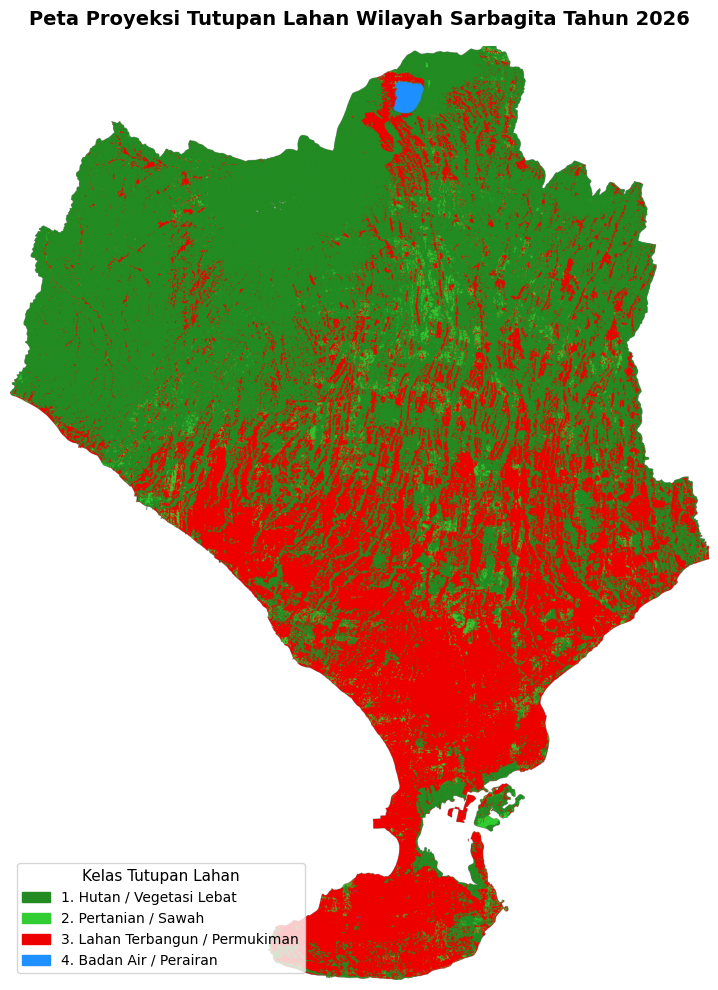

In [22]:
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np
import rasterio

# 1. Pemetaan Kode Kelas Baru (Urut 1 - 4)
color_dict = {
    1: "#228B22",  # Hijau Tua (Hutan / Vegetasi Lebat)
    2: "#32CD32",  # Hijau Muda (Pertanian / Sawah)
    3: "#EE0000",  # Merah (Lahan Terbangun / Permukiman)
    4: "#1E90FF",  # Biru (Badan Air / Perairan)
}

class_names = {
    1: "Hutan / Vegetasi Lebat",
    2: "Pertanian / Sawah",
    3: "Lahan Terbangun / Permukiman",
    4: "Badan Air / Perairan",
}


def plot_landcover_map(raster_path, title):
    with rasterio.open(raster_path) as src:
        data = src.read(1)

    # 2. Remap nilai piksel lama (1, 2, 4, 5) ke kode baru (1, 2, 3, 4)
    data_remapped = np.zeros_like(data, dtype=np.uint8)
    data_remapped[data == 1] = 1  # Hutan
    data_remapped[data == 2] = 2  # Pertanian
    data_remapped[data == 4] = 3  # Lahan Terbangun (Lama: 4 -> Baru: 3)
    data_remapped[data == 5] = 4  # Badan Air (Lama: 5 -> Baru: 4)

    # 3. Custom Colormap urut 1 - 4
    colors = [color_dict[i] for i in sorted(color_dict.keys())]
    cmap = ListedColormap(colors)

    # Masking nilai 0 (NoData)
    data_masked = np.ma.masked_where(data_remapped == 0, data_remapped)

    fig, ax = plt.subplots(figsize=(12, 10))

    # Tampilkan Raster (Nilai 1 sampai 4)
    im = ax.imshow(data_masked, cmap=cmap, vmin=1, vmax=4)

    # 4. Buat Legenda Manual
    patches = [
        mpatches.Patch(
            color=color_dict[code], label=f"{code}. {class_names[code]}"
        )
        for code in sorted(color_dict.keys())
    ]

    ax.legend(
        handles=patches,
        loc="lower left",
        title="Kelas Tutupan Lahan",
        fontsize=10,
        title_fontsize=11,
        frameon=True,
    )

    ax.set_title(title, fontsize=14, fontweight="bold", pad=15)
    ax.axis("off")  # Sembunyikan sumbu koordinat piksel

    plt.tight_layout()
    plt.show()

# Tampilkan Peta 2026
plot_landcover_map(
    "Sarbagita_2026_proyeksi_tutupan_lahan.tif",
    "Peta Proyeksi Tutupan Lahan Wilayah Sarbagita Tahun 2026",
)

**Tabulasi Hasil Uji Akurasi Validitas Model**

In [23]:
import numpy as np
import pandas as pd
import rasterio
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import cohen_kappa_score, confusion_matrix
from sklearn.model_selection import train_test_split

print("1. Memuat raster 2020 & 2023...")
with rasterio.open("Sarbagita_2020_tutupan_lahan.tif") as src20:
    lc_2020 = src20.read(1)

with rasterio.open("Sarbagita_2023_tutupan_lahan.tif") as src23:
    lc_2023 = src23.read(1)

# Remap otomatis jika raster masih mengandalkan kode lama (4: Terbangun, 5: Air)
# 4 -> 3 (Lahan Terbangun / Permukiman)
# 5 -> 4 (Badan Air / Perairan)
for lc_arr in [lc_2020, lc_2023]:
    lc_arr[lc_arr == 4] = 3
    lc_arr[lc_arr == 5] = 4

valid_mask = (
    (lc_2020 > 0) & (lc_2020 <= 4) & (lc_2023 > 0) & (lc_2023 <= 4)
)

# Driving Factors
rows, cols = lc_2020.shape
row_grid, col_grid = np.indices((rows, cols))
y_factor = (row_grid / float(rows)).astype(np.float32)
x_factor = (col_grid / float(cols)).astype(np.float32)
center_y, center_x = rows // 2, cols // 2
dist_center = (
    np.sqrt((row_grid - center_y) ** 2 + (col_grid - center_x) ** 2)
    / np.sqrt(rows**2 + cols**2)
).astype(np.float32)

# Sub-sampling
valid_indices = np.argwhere(valid_mask)
n_samples = min(150000, len(valid_indices))
np.random.seed(42)
sample_idx = valid_indices[
    np.random.choice(len(valid_indices), n_samples, replace=False)
]

r_idx, c_idx = sample_idx[:, 0], sample_idx[:, 1]

X_sub = np.column_stack(
    [
        lc_2020[r_idx, c_idx],
        y_factor[r_idx, c_idx],
        x_factor[r_idx, c_idx],
        dist_center[r_idx, c_idx],
    ]
)
y_sub = lc_2023[r_idx, c_idx]

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

# Training Model
print("2. Melatih model & mengevaluasi metrik akurasi (4 Kelas)...")
model = RandomForestClassifier(
    n_estimators=100, max_depth=20, random_state=42, n_jobs=-1
)
model.fit(X_train, y_train)

# Prediksi
y_pred = model.predict(X_test)

# Confusion Matrix (4 Kelas: 1, 2, 3, 4)
all_labels = [1, 2, 3, 4]
cm = confusion_matrix(y_test, y_pred, labels=all_labels)
kappa = cohen_kappa_score(y_test, y_pred, labels=all_labels)
overall_accuracy = np.trace(cm) / float(np.sum(cm))

# Perhitungan Producer's & User's Accuracy
with np.errstate(divide="ignore", invalid="ignore"):
    row_sum = np.sum(cm, axis=1)  # Actual / Ground Truth
    col_sum = np.sum(cm, axis=0)  # Predicted

    producer_accuracy = np.where(row_sum > 0, np.diag(cm) / row_sum, 0.0)
    user_accuracy = np.where(col_sum > 0, np.diag(cm) / col_sum, 0.0)

class_names = [
    "1. Hutan / Vegetasi Lebat",
    "2. Pertanian / Sawah",
    "3. Lahan Terbangun / Permukiman",
    "4. Badan Air / Perairan",
]

# Tabulasi Kelas
accuracy_df = pd.DataFrame(
    {
        "Kelas Tutupan Lahan": class_names,
        "Producer's Accuracy (%)": np.round(producer_accuracy * 100, 2),
        "User's Accuracy (%)": np.round(user_accuracy * 100, 2),
    }
)

# Format Ekspor CSV & Excel
accuracy_df.to_csv("tabulasi_uji_akurasi_sarbagita.csv", index=False)
accuracy_df.to_excel("tabulasi_uji_akurasi_sarbagita.xlsx", index=False)

# Cetak Tampilan Tabulasi
print("\n" + "=" * 60)
print("TABULASI UJI AKURASI VALIDITAS PREDIKSI TUTUPAN LAHAN")
print("=" * 60)
print(accuracy_df.to_string(index=False))
print("-" * 60)
print(f"Overall Accuracy    : {overall_accuracy * 100:.2f}%")
print(f"Cohen's Kappa Index : {kappa:.4f}")
print("=" * 60)
print(
    "\nBERHASIL! [4e] File tabulasi tersimpan di: tabulasi_uji_akurasi_sarbagita.csv & .xlsx"
)

1. Memuat raster 2020 & 2023...
2. Melatih model & mengevaluasi metrik akurasi (4 Kelas)...

TABULASI UJI AKURASI VALIDITAS PREDIKSI TUTUPAN LAHAN
            Kelas Tutupan Lahan  Producer's Accuracy (%)  User's Accuracy (%)
      1. Hutan / Vegetasi Lebat                    92.29                84.48
           2. Pertanian / Sawah                    19.18                40.29
3. Lahan Terbangun / Permukiman                    78.44                77.51
        4. Badan Air / Perairan                    93.75               100.00
------------------------------------------------------------
Overall Accuracy    : 80.04%
Cohen's Kappa Index : 0.6234

BERHASIL! [4e] File tabulasi tersimpan di: tabulasi_uji_akurasi_sarbagita.csv & .xlsx
